# Loan Approval Prediction Using Machine Learning

## Project Overview

This project aims to predict whether a loan application should be approved or rejected based on applicant-related and financial attributes using Support Vector Machine (SVM) algorithm.

### Problem Statement
- **Task**: Binary Classification (Approved/Rejected)
- **Algorithm**: Support Vector Machine (SVM)
- **Dataset**: Loan Application Dataset with 20,000 records

### Project Structure
1. Data Loading and Exploration
2. Data Preprocessing and Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Training (SVM)
6. Model Evaluation
7. Results and Insights

---

## Dataset Information

### Dataset Source
- **Source**: Custom Loan Dataset (loan_dataset_20000.csv)
- **Size**: 20,000 records
- **Features**: 22 attributes (21 independent variables + 1 target variable)
- **Type**: Structured tabular data
- **Domain**: Financial Services - Loan Application Processing

### Dataset Attributes Description

The dataset contains comprehensive information about loan applicants and their financial history:

#### Demographic Features:
1. **age**: Age of the applicant (integer)
2. **gender**: Gender of the applicant (Male/Female/Other)
3. **marital_status**: Marital status (Single/Married/Divorced/Widowed)
4. **education_level**: Highest education attained (High School/Bachelor's/Master's/PhD/Other)

#### Financial Features:
5. **annual_income**: Total annual income in dollars (float)
6. **monthly_income**: Monthly income in dollars (float)
7. **employment_status**: Current employment status (Employed/Unemployed/Self-employed/Student/Retired)
8. **debt_to_income_ratio**: Ratio of monthly debt payments to monthly income (float, 0-1)
9. **credit_score**: Credit score of the applicant (integer, 300-850)
10. **current_balance**: Current balance on existing credit accounts (float)
11. **total_credit_limit**: Total credit limit across all accounts (float)

#### Loan-Specific Features:
12. **loan_amount**: Requested loan amount in dollars (float)
13. **loan_purpose**: Purpose of the loan (Car/Home/Education/Business/Medical/Debt consolidation/Vacation/Other)
14. **interest_rate**: Interest rate offered for the loan (float, percentage)
15. **loan_term**: Loan repayment term in months (integer)
16. **installment**: Monthly installment amount (float)
17. **grade_subgrade**: Risk grade assigned to the loan (A1-G5)

#### Credit History Features:
18. **num_of_open_accounts**: Number of open credit accounts (integer)
19. **delinquency_history**: History of delinquencies (0=No, 1=Yes, or count)
20. **public_records**: Number of public records (bankruptcies, tax liens, etc.) (integer)
21. **num_of_delinquencies**: Total number of delinquency occurrences (integer)

#### Target Variable:
22. **loan_paid_back**: Whether the loan was paid back successfully (1=Yes, 0=No) - **TARGET VARIABLE**

### Dataset Context
This dataset represents real-world loan application data typically used by financial institutions to assess credit risk and make lending decisions. The features capture various aspects of an applicant's financial health, credit history, and loan characteristics, making it suitable for binary classification tasks to predict loan repayment likelihood.

---

## 1. Import Required Libraries

In [66]:
%pip install seaborn
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Machine Learning - Model
from sklearn.svm import SVC

# Machine Learning - Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ All libraries imported successfully!")

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
✓ All libraries imported successfully!



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Load and Explore the Dataset

In [84]:
# Load the dataset
df = pd.read_csv('loan_dataset_20000.csv')

# Normalize column names to avoid hidden whitespace mismatches
df.columns = [col.strip() for col in df.columns]

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Number of records: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")
print(f"Target present (loan_paid_back): {'loan_paid_back' in df.columns}")

Dataset loaded successfully!
Dataset shape: (20000, 22)
Number of records: 20000
Number of features: 22
Target present (loan_paid_back): True


In [68]:
# Display first few rows
print("\n=== First 5 rows of the dataset ===")
df.head()


=== First 5 rows of the dataset ===


,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,loan_purpose,interest_rate,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,Car,13.39,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,Debt consolidation,17.81,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,Business,9.53,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,Other,7.99,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,Car,15.20,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [69]:
# Display dataset information
print("\n=== Dataset Information ===")
df.info()


=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  obj

In [70]:
# Statistical summary
print("\n=== Statistical Summary ===")
df.describe()


=== Statistical Summary ===


,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,48.027000,43549.637765,3629.136466,0.177019,679.25695,15129.300909,12.400627,43.22280,455.625794,5.011800,48649.824769,24333.394631,1.990150,0.061800,2.489150,0.799900
std,15.829352,28668.579671,2389.048326,0.105059,69.63858,8605.405513,2.442729,11.00838,274.622125,2.244529,32423.378128,22313.845395,1.474945,0.285105,1.631384,0.400085
min,21.000000,6000.000000,500.000000,0.010000,373.00000,500.000000,3.140000,36.00000,9.430000,0.000000,6157.800000,496.350000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,24260.752500,2021.730000,0.096000,632.00000,8852.695000,10.740000,36.00000,253.910000,3.000000,27180.492500,9592.572500,1.000000,0.000000,1.000000,1.000000
50%,48.000000,36585.260000,3048.770000,0.160000,680.00000,14946.170000,12.400000,36.00000,435.595000,5.000000,40241.615000,18334.555000,2.000000,0.000000,2.000000,1.000000
75%,62.000000,54677.917500,4556.495000,0.241000,727.00000,20998.867500,14.002500,60.00000,633.595000,6.000000,60361.257500,31743.327500,3.000000,0.000000,3.000000,1.000000
max,75.000000,400000.000000,33333.330000,0.667000,850.00000,49039.690000,22.510000,60.00000,1685.400000,15.000000,454394.190000,352177.900000,11.000000,2.000000,11.000000,1.000000


In [71]:
# Check for missing values
print("\n=== Missing Values Analysis ===")
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(
    by='Missing Values', ascending=False
)

if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing values found in the dataset!")


=== Missing Values Analysis ===
No missing values found in the dataset!


In [72]:
# Check for duplicate records
duplicates = df.duplicated().sum()
print(f"\n=== Duplicate Records ===")
print(f"Number of duplicate records: {duplicates}")


=== Duplicate Records ===
Number of duplicate records: 0


## 3. Exploratory Data Analysis (EDA)

In [73]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")

Categorical columns (6): ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']

Numerical columns (16): ['age', 'annual_income', 'monthly_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_term', 'installment', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'public_records', 'num_of_delinquencies', 'loan_paid_back']


In [85]:
# Target variable distribution
# Robust target detection to avoid KeyError later
normalized_cols = {col.strip().lower(): col for col in df.columns}

if 'loan_paid_back' in normalized_cols:
    target_col = normalized_cols['loan_paid_back']
elif 'loan_status' in normalized_cols:
    target_col = normalized_cols['loan_status']
else:
    fallback = [c for c in df.columns if 'paid_back' in c.lower() or 'status' in c.lower()]
    if not fallback:
        raise ValueError("Target column not found. Expected one of: loan_paid_back, loan_status")
    target_col = fallback[0]

print(f"\n=== Target Variable: {target_col} ===")
print(df[target_col].value_counts())
print(f"\nPercentage Distribution:")
print(df[target_col].value_counts(normalize=True) * 100)
print(f"\nTarget unique values: {df[target_col].nunique()}")


=== Target Variable: loan_paid_back ===
loan_paid_back
1    15998
0     4002
Name: count, dtype: int64

Percentage Distribution:
loan_paid_back
1    79.99
0    20.01
Name: proportion, dtype: float64

Target unique values: 2


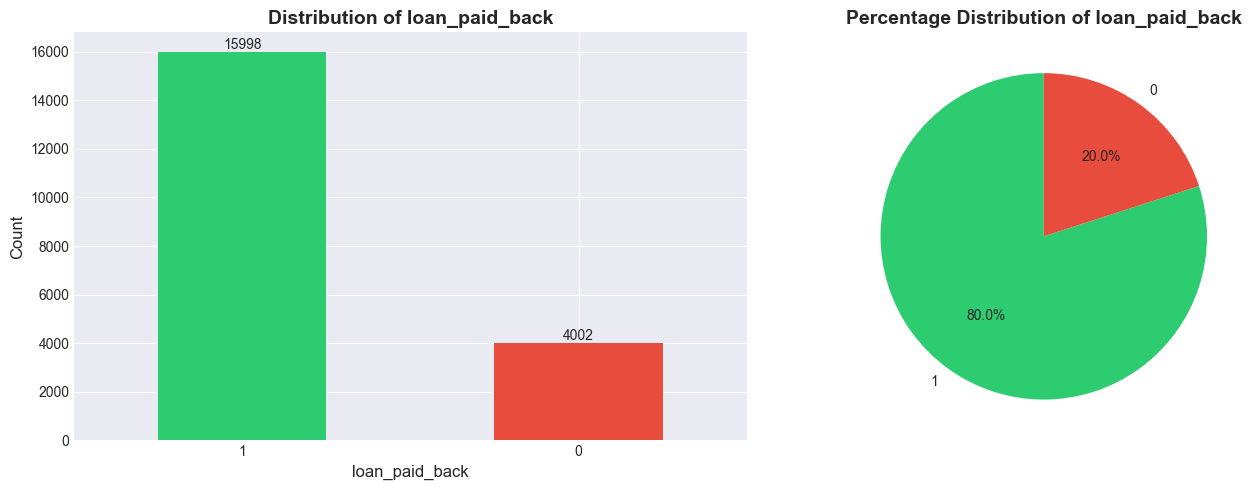

In [75]:
# Visualize target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Count plot
df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title(f'Distribution of {target_col}', fontsize=14, fontweight='bold')
axes[0].set_xlabel(target_col, fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)

# Add value labels on bars
for container in axes[0].containers:
    axes[0].bar_label(container)

# Pie chart
df[target_col].value_counts().plot(
    kind='pie', 
    ax=axes[1], 
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90
)
axes[1].set_title(f'Percentage Distribution of {target_col}', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

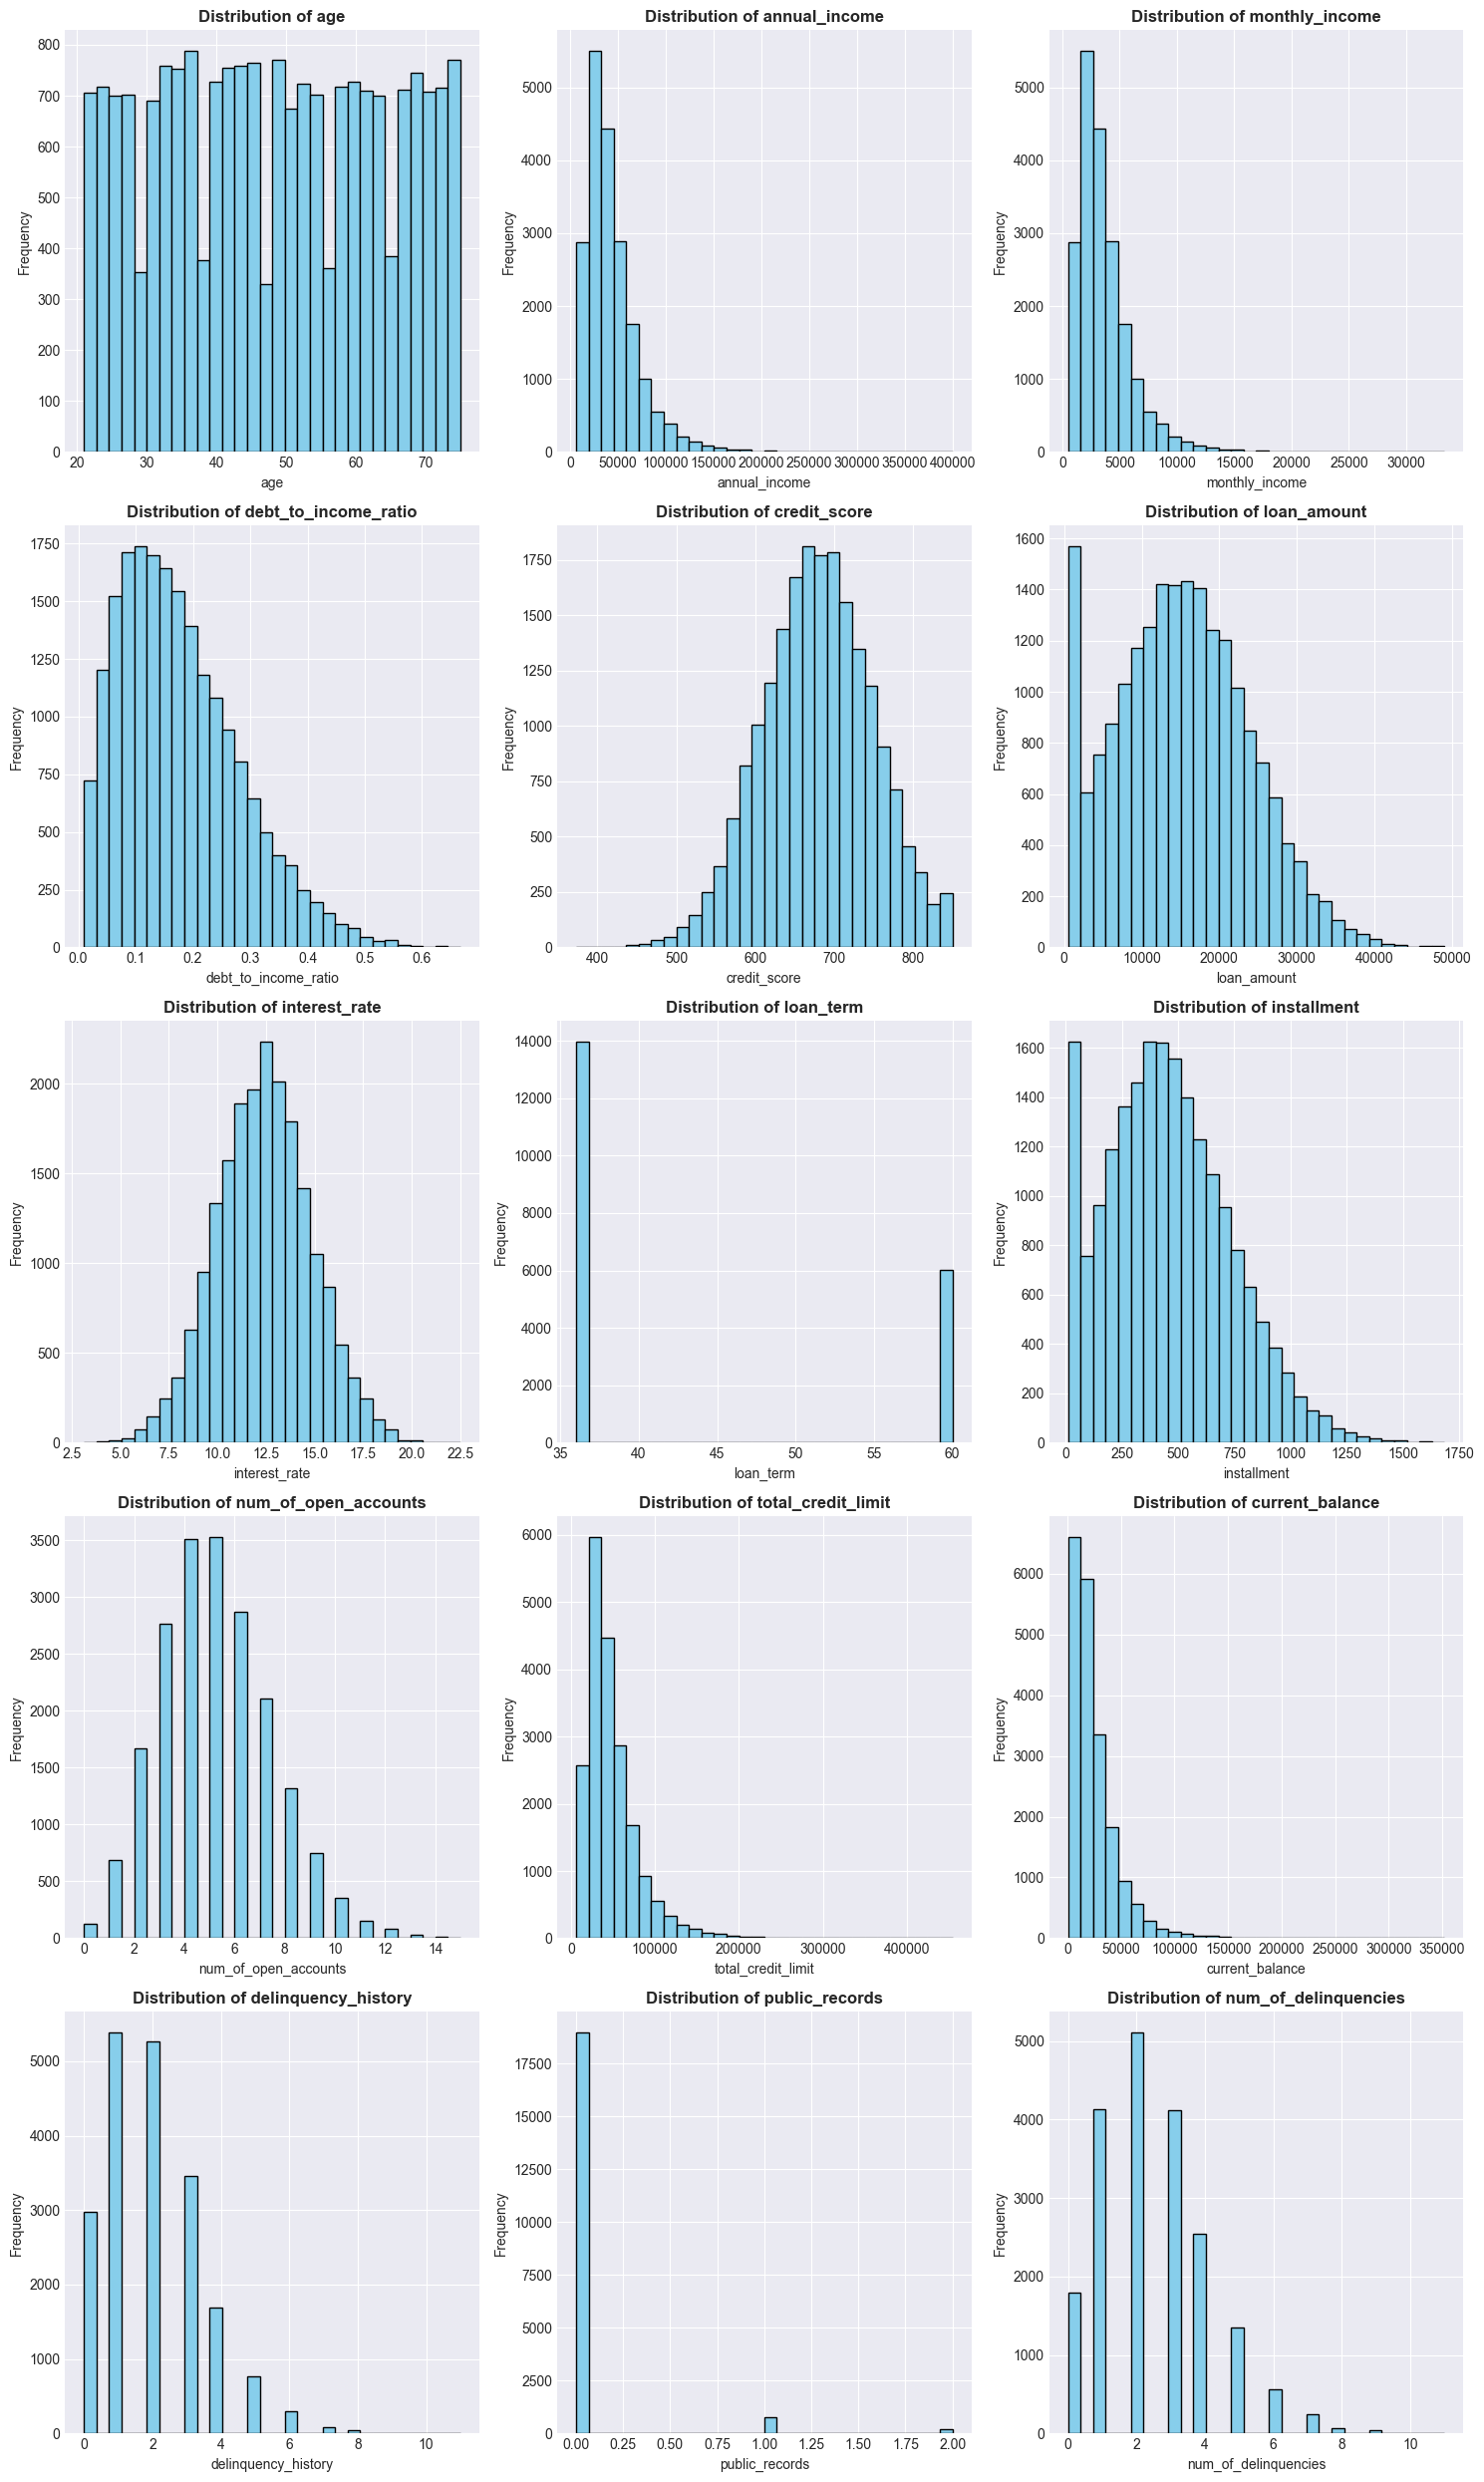

In [76]:
# Distribution of numerical features
if len(numerical_cols) > 0:
    # Remove ID columns if any
    plot_numerical = [col for col in numerical_cols if 'id' not in col.lower()]
    
    if len(plot_numerical) > 0:
        n_cols = min(3, len(plot_numerical))
        n_rows = (len(plot_numerical) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
        axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes
        
        for idx, col in enumerate(plot_numerical):
            df[col].hist(bins=30, ax=axes[idx], color='skyblue', edgecolor='black')
            axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Frequency')
        
        # Hide empty subplots
        for idx in range(len(plot_numerical), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()

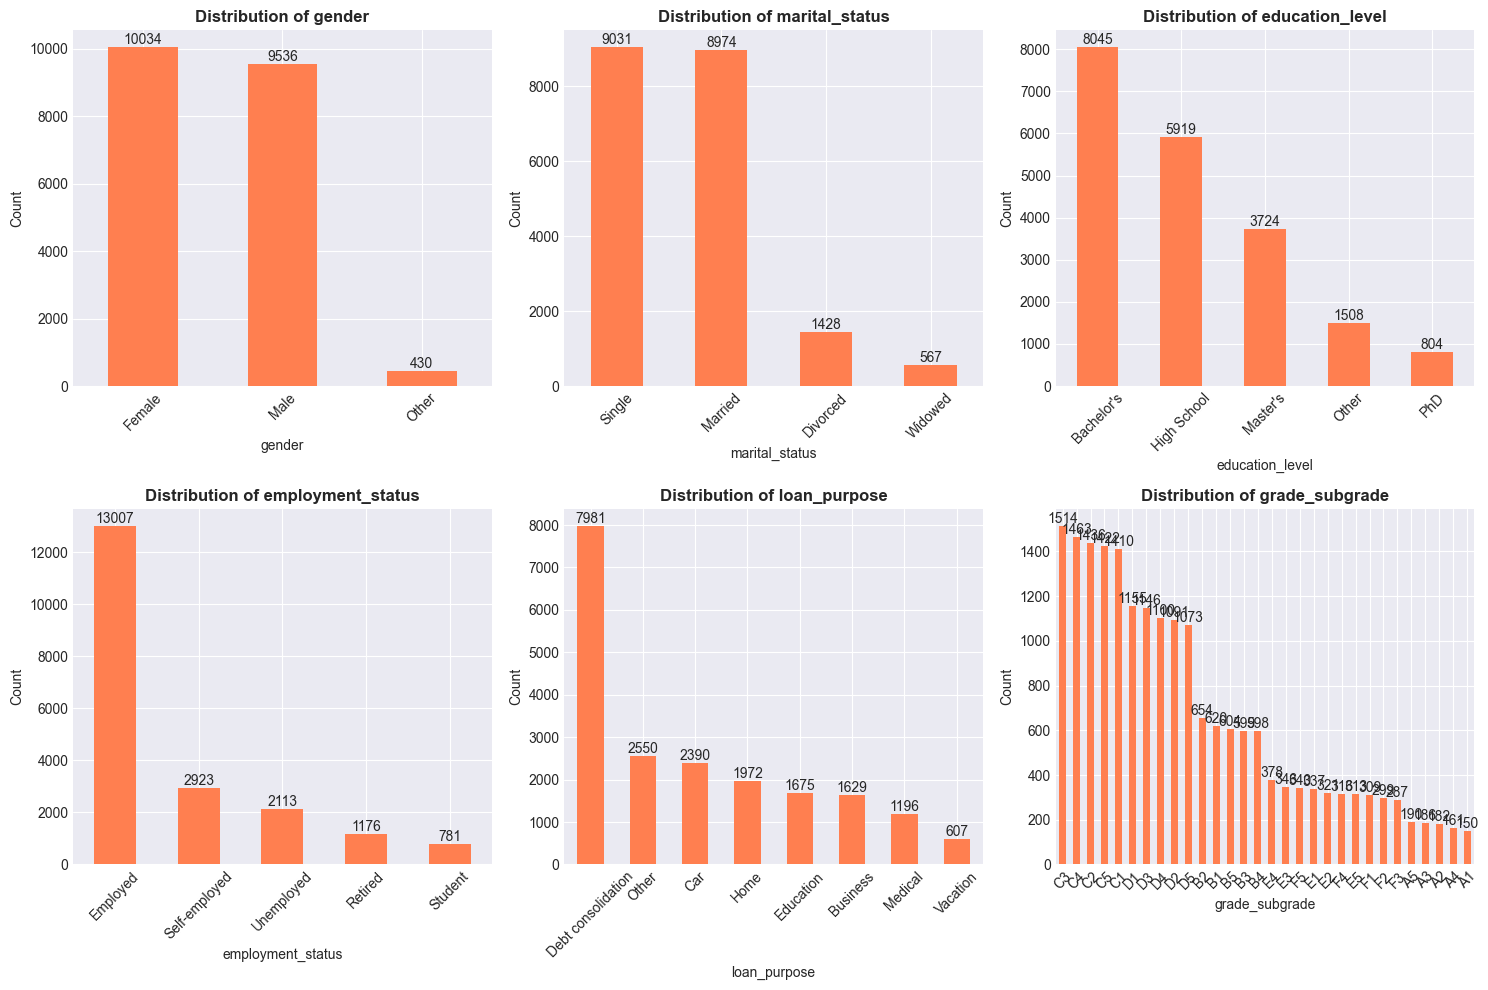

In [77]:
# Distribution of categorical features
if len(categorical_cols) > 1:  # More than just target variable
    plot_categorical = [col for col in categorical_cols if col != target_col]
    
    if len(plot_categorical) > 0:
        n_cols = min(3, len(plot_categorical))
        n_rows = (len(plot_categorical) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
        axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes
        for idx, col in enumerate(plot_categorical):
            df[col].value_counts().plot(kind='bar', ax=axes[idx], color='coral')
            axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Count')
            axes[idx].tick_params(axis='x', rotation=45)
            
            # Add value labels
            for container in axes[idx].containers:
                axes[idx].bar_label(container)
        
        # Hide empty subplots
        for idx in range(len(plot_categorical), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()

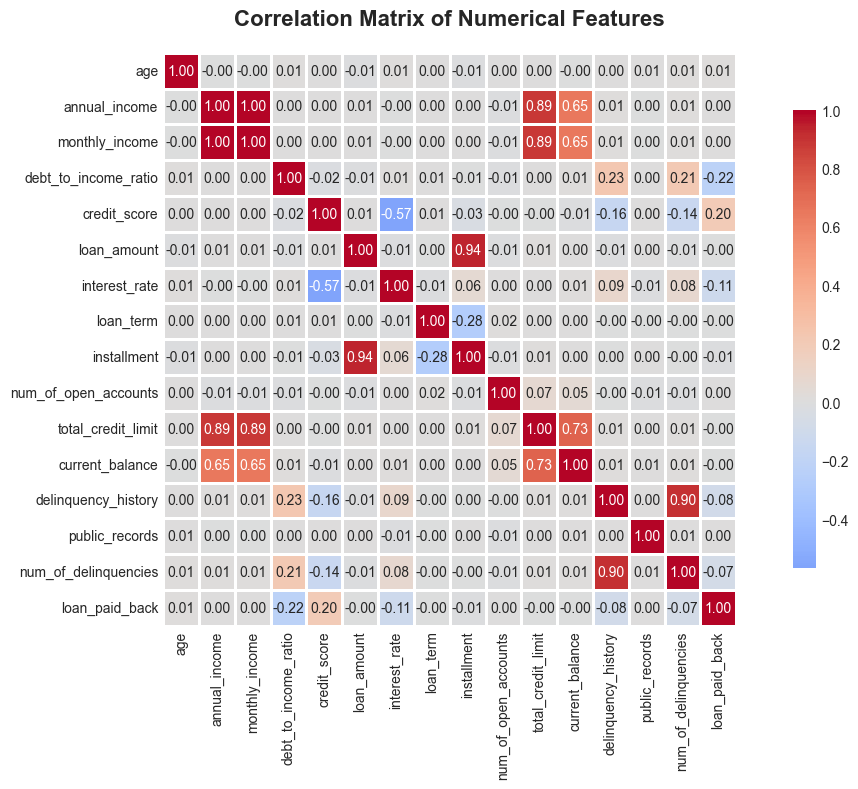

In [78]:
# Correlation matrix for numerical features
if len(numerical_cols) > 1:
    plt.figure(figsize=(12, 8))
    
    # Calculate correlation matrix
    corr_matrix = df[numerical_cols].corr()
    
    # Create heatmap
    sns.heatmap(
        corr_matrix, 
        annot=True, 
        fmt='.2f', 
        cmap='coolwarm', 
        center=0,
        square=True,
        linewidths=1,
        cbar_kws={"shrink": 0.8}
    )
    
    plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

## 4. Data Preprocessing

In [89]:
# Create a copy of the dataframe for preprocessing
df_processed = df.copy()

print("Original dataset shape:", df.shape)
print("Processing dataset...")

Original dataset shape: (20000, 22)
Processing dataset...


In [90]:
# Remove duplicate records if any
if duplicates > 0:
    df_processed = df_processed.drop_duplicates()
    print(f"Removed {duplicates} duplicate records")

print(f"Dataset shape after removing duplicates: {df_processed.shape}")

Dataset shape after removing duplicates: (20000, 22)


In [91]:
# Drop true identifier columns only (do not drop columns like 'loan_paid_back')
id_columns = []
for col in df_processed.columns:
    c = col.strip().lower()
    # Accept common identifier patterns only
    if c == 'id' or c.endswith('_id') or c.startswith('id_'):
        id_columns.append(col)

if id_columns:
    print(f"Dropping ID columns: {id_columns}")
    df_processed = df_processed.drop(columns=id_columns)
    print(f"Dataset shape after dropping ID columns: {df_processed.shape}")
else:
    print("No true ID columns found to drop.")

No true ID columns found to drop.


In [92]:
# Handle missing values
print("\n=== Handling Missing Values ===")

# For numerical columns: impute with median
numerical_cols_updated = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()

if len(numerical_cols_updated) > 0:
    imputer_num = SimpleImputer(strategy='median')
    df_processed[numerical_cols_updated] = imputer_num.fit_transform(
        df_processed[numerical_cols_updated]
    )
    print(f"✓ Imputed missing values in numerical columns with median")

# For categorical columns: impute with mode
categorical_cols_updated = df_processed.select_dtypes(include=['object']).columns.tolist()

if len(categorical_cols_updated) > 0:
    imputer_cat = SimpleImputer(strategy='most_frequent')
    df_processed[categorical_cols_updated] = imputer_cat.fit_transform(
        df_processed[categorical_cols_updated]
    )
    print(f"✓ Imputed missing values in categorical columns with mode")

# Verify no missing values remain
print(f"\nMissing values after imputation: {df_processed.isnull().sum().sum()}")


=== Handling Missing Values ===
✓ Imputed missing values in numerical columns with median
✓ Imputed missing values in categorical columns with mode

Missing values after imputation: 0


In [93]:
# Encode categorical variables
print("\n=== Encoding Categorical Variables ===")

# Ensure target column exists in processed dataframe
df_processed.columns = [col.strip() for col in df_processed.columns]
if target_col not in df_processed.columns:
    normalized_proc = {col.strip().lower(): col for col in df_processed.columns}
    if target_col.strip().lower() in normalized_proc:
        target_col = normalized_proc[target_col.strip().lower()]
    elif 'loan_paid_back' in normalized_proc:
        target_col = normalized_proc['loan_paid_back']
    else:
        raise KeyError(f"Target column '{target_col}' not found in processed data. Available columns: {df_processed.columns.tolist()}")

# Separate target from features
X = df_processed.drop(columns=[target_col])
y = df_processed[target_col]

# Encode target variable
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print(f"Target variable encoding: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

# Encode categorical features
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

label_encoders = {}
X_encoded = X.copy()

for col in categorical_features:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])
    label_encoders[col] = le

print(f"Encoded {len(categorical_features)} categorical columns")
print(f"\nFeatures shape: {X_encoded.shape}")
print(f"Target shape: {y_encoded.shape}")


=== Encoding Categorical Variables ===
Target variable encoding: {0.0: 0, 1.0: 1}
Encoded 6 categorical columns

Features shape: (20000, 21)
Target shape: (20000,)


## 5. Feature Scaling and Train-Test Split

In [94]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y_encoded, 
    test_size=0.2, 
    random_state=42,
    stratify=y_encoded
)

print("=== Train-Test Split ===")
print(f"Training set size: {X_train.shape[0]} samples ({(X_train.shape[0]/len(X_encoded))*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} samples ({(X_test.shape[0]/len(X_encoded))*100:.1f}%)")
print(f"Number of features: {X_train.shape[1]}")

=== Train-Test Split ===
Training set size: 16000 samples (80.0%)
Test set size: 4000 samples (20.0%)
Number of features: 21


In [95]:
# Feature scaling (important for SVM)
print("\n=== Feature Scaling ===")
print("Applying StandardScaler to normalize features...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Feature scaling completed")
print(f"Scaled training set shape: {X_train_scaled.shape}")
print(f"Scaled test set shape: {X_test_scaled.shape}")


=== Feature Scaling ===
Applying StandardScaler to normalize features...
✓ Feature scaling completed
Scaled training set shape: (16000, 21)
Scaled test set shape: (4000, 21)


In [96]:
# Display class distribution in train and test sets
train_dist = pd.Series(y_train).value_counts()
test_dist = pd.Series(y_test).value_counts()

print("\n=== Class Distribution ===")
print("\nTraining set:")
for idx, count in train_dist.items():
    class_name = le_target.inverse_transform([idx])[0]
    print(f"  {class_name}: {count} ({count/len(y_train)*100:.2f}%)")

print("\nTest set:")
for idx, count in test_dist.items():
    class_name = le_target.inverse_transform([idx])[0]
    print(f"  {class_name}: {count} ({count/len(y_test)*100:.2f}%)")


=== Class Distribution ===

Training set:
  1.0: 12798 (79.99%)
  0.0: 3202 (20.01%)

Test set:
  1.0: 3200 (80.00%)
  0.0: 800 (20.00%)


# 6. Model Training - Support Vector Machine (SVM)

## Support Vector Machine (SVM) - Algorithm Background

### What is Support Vector Machine?

Support Vector Machine (SVM) is a powerful supervised machine learning algorithm primarily used for classification tasks. It was developed by Vladimir Vapnik and his colleagues at AT&T Bell Laboratories in the 1990s.

### How SVM Works

SVM works by finding the optimal hyperplane that best separates different classes in the feature space. The key concepts are:

1. **Hyperplane**: A decision boundary that separates data points of different classes
2. **Support Vectors**: Data points closest to the hyperplane that influence its position and orientation
3. **Margin**: The distance between the hyperplane and the nearest data points from either class
4. **Kernel Trick**: A method to transform data into higher dimensions to find a separating hyperplane for non-linearly separable data

The algorithm aims to maximize the margin between classes, which typically leads to better generalization on unseen data.

### Types of SVM Kernels

1. **Linear Kernel**: For linearly separable data
2. **RBF (Radial Basis Function) Kernel**: For non-linear data (most commonly used)
3. **Polynomial Kernel**: For non-linear relationships with polynomial features
4. **Sigmoid Kernel**: Similar to neural network activation functions

### Why SVM for Loan Approval Prediction?

#### Justification for Algorithm Selection:

1. **High-Dimensional Data Handling**: Our dataset has 21 features, and SVM performs exceptionally well in high-dimensional spaces

2. **Robust to Overfitting**: SVM's margin maximization principle makes it less prone to overfitting, especially with proper regularization (C parameter)

3. **Effective for Binary Classification**: Loan approval is a binary decision (approved/rejected), which is SVM's primary strength

4. **Non-Linear Decision Boundaries**: Financial data often has complex, non-linear relationships. SVM with RBF kernel can capture these patterns effectively

5. **Memory Efficient**: SVM uses only support vectors (subset of training data) for prediction, making it memory efficient

6. **Strong Theoretical Foundation**: Based on statistical learning theory and structural risk minimization principle

7. **Proven Performance**: SVM has been successfully applied in various financial applications including credit scoring and risk assessment

#### Advantages of SVM:
- Effective in high-dimensional spaces
- Memory efficient (uses support vectors)
- Versatile (different kernel functions)
- Robust against overfitting
- Excellent for binary classification

#### Limitations of SVM:
- Computationally intensive for large datasets
- Requires careful hyperparameter tuning (C, gamma, kernel)
- Sensitive to feature scaling (requires standardization)
- Difficult to interpret compared to decision trees
- Training time increases with dataset size

### Hyperparameters to Tune:

1. **C (Regularization Parameter)**: Controls trade-off between smooth decision boundary and classifying training points correctly
2. **Gamma**: Defines how far the influence of a single training example reaches
3. **Kernel**: Type of kernel function to use for transformation

---

## 6.1 Baseline SVM Model

In [97]:
# Train baseline SVM model
print("=== Training Baseline SVM Model ===")
print("Model: Support Vector Machine with RBF kernel\n")

# Use balanced class weights for better performance on imbalanced classes
svm_baseline = SVC(kernel='rbf', class_weight='balanced', random_state=42, max_iter=5000)

# Train the model
print(f"Training on {len(X_train_scaled)} samples...")
svm_baseline.fit(X_train_scaled, y_train)

print("✓ Baseline SVM model trained successfully!")
print(f"Number of support vectors by class: {svm_baseline.n_support_}")
print(f"Total support vectors: {sum(svm_baseline.n_support_)}")

=== Training Baseline SVM Model ===
Model: Support Vector Machine with RBF kernel

Training on 16000 samples...
✓ Baseline SVM model trained successfully!
Number of support vectors by class: [1556 4645]
Total support vectors: 6201


In [98]:
# Make predictions with baseline model on test set
print("\n=== Baseline Model Predictions ===")
y_pred_baseline = svm_baseline.predict(X_test_scaled)

# Calculate evaluation metrics for baseline model
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline, average='weighted')
recall_baseline = recall_score(y_test, y_pred_baseline, average='weighted')
f1_baseline = f1_score(y_test, y_pred_baseline, average='weighted')

print("Baseline SVM Model Performance:")
print(f"Accuracy:  {accuracy_baseline:.4f} ({accuracy_baseline*100:.2f}%)")
print(f"Precision: {precision_baseline:.4f}")
print(f"Recall:    {recall_baseline:.4f}")
print(f"F1-Score:  {f1_baseline:.4f}")

# Display baseline confusion matrix
print("\nBaseline Confusion Matrix:")
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
print(cm_baseline)


=== Baseline Model Predictions ===
Baseline SVM Model Performance:
Accuracy:  0.7145 (71.45%)
Precision: 0.8296
Recall:    0.7145
F1-Score:  0.7422

Baseline Confusion Matrix:
[[ 654  146]
 [ 996 2204]]


## 6.2 Hyperparameter Tuning with GridSearchCV

In [99]:
# Hyperparameter tuning with faster RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

print("=== Hyperparameter Tuning with RandomizedSearchCV (FAST) ===")
print("Using reduced search space for faster training...\n")

param_distributions = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear'],
    'class_weight': ['balanced']
}

# Much faster than full grid: 12 random combinations x 3 folds = 36 fits
grid_search = RandomizedSearchCV(
    SVC(random_state=42),
    param_distributions=param_distributions,
    n_iter=12,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

print("Fitting 12 parameter combinations with 3-fold CV (36 fits total)...")
grid_search.fit(X_train_scaled, y_train)

print("\n✓ Hyperparameter search completed!")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

=== Hyperparameter Tuning with RandomizedSearchCV (FAST) ===
Using reduced search space for faster training...

Fitting 12 parameter combinations with 3-fold CV (36 fits total)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

✓ Hyperparameter search completed!
Best parameters: {'kernel': 'rbf', 'gamma': 0.1, 'class_weight': 'balanced', 'C': 100}
Best cross-validation score: 0.8365


In [100]:
# Get the best model
svm_optimized = grid_search.best_estimator_

# Make predictions with optimized model
y_pred_optimized = svm_optimized.predict(X_test_scaled)

# Calculate evaluation metrics for optimized model
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
precision_optimized = precision_score(y_test, y_pred_optimized, average='weighted')
recall_optimized = recall_score(y_test, y_pred_optimized, average='weighted')
f1_optimized = f1_score(y_test, y_pred_optimized, average='weighted')

print("\n=== Optimized SVM Model Performance ===")
print(f"Accuracy:  {accuracy_optimized:.4f} ({accuracy_optimized*100:.2f}%)")
print(f"Precision: {precision_optimized:.4f}")
print(f"Recall:    {recall_optimized:.4f}")
print(f"F1-Score:  {f1_optimized:.4f}")


=== Optimized SVM Model Performance ===
Accuracy:  0.8380 (83.80%)
Precision: 0.8341
Recall:    0.8380
F1-Score:  0.8358


In [ ]:
# Compare baseline vs optimized model
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Baseline SVM': [
        f"{accuracy_baseline:.4f}",
        f"{precision_baseline:.4f}",
        f"{recall_baseline:.4f}",
        f"{f1_baseline:.4f}"
    ],
    'Optimized SVM': [
        f"{accuracy_optimized:.4f}",
        f"{precision_optimized:.4f}",
        f"{recall_optimized:.4f}",
        f"{f1_optimized:.4f}"
    ],
    'Improvement': [
        f"{(accuracy_optimized - accuracy_baseline):.4f}",
        f"{(precision_optimized - precision_baseline):.4f}",
        f"{(recall_optimized - recall_baseline):.4f}",
        f"{(f1_optimized - f1_baseline):.4f}"
    ]
})

print("\n=== Model Comparison ===")
print(comparison_df.to_string(index=False))

## 6.3 Cross-Validation Analysis


In [101]:
# Perform cross-validation on optimized model
print("=== Cross-Validation Analysis ===")
print("Performing 5-fold cross-validation (faster than 10-fold)...\n")

cv_scores = cross_val_score(
    svm_optimized, 
    X_train_scaled, 
    y_train, 
    cv=5,  # Reduced from 10 to 5 for speed
    scoring='accuracy',
    n_jobs=-1
)

print(f"Cross-validation scores: {cv_scores}")
print(f"\nMean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"Min CV Score:  {cv_scores.min():.4f}")
print(f"Max CV Score:  {cv_scores.max():.4f}")

# ============================================
# SAVE THE TRAINED MODEL
# ============================================
import joblib

print("\n=== Saving Trained Model ===")
joblib.dump(svm_optimized, 'svm_loan_model_optimized.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
joblib.dump(le_target, 'target_encoder.pkl')

print("✓ Model saved: svm_loan_model_optimized.pkl")
print("✓ Scaler saved: scaler.pkl")
print("✓ Encoders saved: label_encoders.pkl, target_encoder.pkl")

=== Cross-Validation Analysis ===
Performing 5-fold cross-validation (faster than 10-fold)...

Cross-validation scores: [0.834375  0.8428125 0.8290625 0.8378125 0.8459375]

Mean CV Score: 0.8380 (+/- 0.0120)
Min CV Score:  0.8291
Max CV Score:  0.8459

=== Saving Trained Model ===
✓ Model saved: svm_loan_model_optimized.pkl
✓ Scaler saved: scaler.pkl
✓ Encoders saved: label_encoders.pkl, target_encoder.pkl


In [102]:
# ============================================
# SAVE TRAINED MODEL AND PREPROCESSING OBJECTS
# ============================================
import joblib

print("=== Saving Model Artifacts ===\n")

# Save the optimized SVM model
joblib.dump(svm_optimized, 'svm_loan_model_optimized.pkl')
print("\u2713 Model saved: svm_loan_model_optimized.pkl")

# Save the scaler (CRITICAL for making predictions on new data)
joblib.dump(scaler, 'scaler.pkl')
print("\u2713 Scaler saved: scaler.pkl")

# Save label encoders for categorical features
joblib.dump(label_encoders, 'label_encoders.pkl')
print("\u2713 Label encoders saved: label_encoders.pkl")

# Save target encoder
joblib.dump(le_target, 'target_encoder.pkl')
print("\u2713 Target encoder saved: target_encoder.pkl")

print("\n=== Model Artifacts Saved Successfully ===")
print("You can now use these files to make predictions on new loan applications!")

# Quick verification - reload and test
print("\n=== Verification: Reloading Model ===")
loaded_model = joblib.load('svm_loan_model_optimized.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# Test on a few samples
sample_indices = [0, 1, 2, 3, 4]
X_sample = X_test_scaled[sample_indices]
y_sample_pred = loaded_model.predict(X_sample)
y_sample_actual = y_test[sample_indices]

print(f"\nSample predictions using loaded model:")
for i, (pred, actual) in enumerate(zip(y_sample_pred, y_sample_actual)):
    status_pred = le_target.inverse_transform([pred])[0]
    status_actual = le_target.inverse_transform([actual])[0]
    match = "\u2713" if pred == actual else "\u2717"
    print(f"  Sample {i+1}: Predicted={status_pred}, Actual={status_actual} {match}")

print("\n\u2713 Model reload and prediction test successful!")

=== Saving Model Artifacts ===

✓ Model saved: svm_loan_model_optimized.pkl
✓ Scaler saved: scaler.pkl
✓ Label encoders saved: label_encoders.pkl
✓ Target encoder saved: target_encoder.pkl

=== Model Artifacts Saved Successfully ===
You can now use these files to make predictions on new loan applications!

=== Verification: Reloading Model ===

Sample predictions using loaded model:
  Sample 1: Predicted=1.0, Actual=1.0 ✓
  Sample 2: Predicted=1.0, Actual=1.0 ✓
  Sample 3: Predicted=1.0, Actual=1.0 ✓
  Sample 4: Predicted=0.0, Actual=0.0 ✓
  Sample 5: Predicted=0.0, Actual=1.0 ✗

✓ Model reload and prediction test successful!


# 7. Model Evaluation and Visualization

## 7.1 Classification Report

In [ ]:
# Detailed classification report
print("=== Classification Report ===")
print("\nOptimized SVM Model:\n")

# Get class names
target_names = le_target.classes_

print(classification_report(
    y_test, 
    y_pred_optimized, 
    target_names=target_names
))

## 7.2 Confusion Matrix

In [ ]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_optimized)

# Visualize confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    cbar_kws={'label': 'Count'}
)

plt.title('Confusion Matrix - Optimized SVM Model', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)

# Add percentage annotations
for i in range(len(cm)):
    for j in range(len(cm)):
        percentage = cm[i, j] / cm[i].sum() * 100
        plt.text(
            j + 0.5, 
            i + 0.7, 
            f'({percentage:.1f}%)', 
            ha='center', 
            va='center',
            fontsize=10,
            color='gray'
        )

plt.tight_layout()
plt.show()

# Print confusion matrix metrics
print("\nConfusion Matrix Breakdown:")
tn, fp, fn, tp = cm.ravel() if len(cm.ravel()) == 4 else (cm[0,0], cm[0,1], cm[1,0], cm[1,1])
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

## 7.3 ROC Curve and AUC Score

In [ ]:
# Calculate ROC curve and AUC score
# Get probability scores for positive class
svm_optimized_prob = SVC(
    **grid_search.best_params_, 
    probability=True, 
    random_state=42
)
svm_optimized_prob.fit(X_train_scaled, y_train)
y_pred_proba = svm_optimized_prob.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(10, 8))

plt.plot(
    fpr, 
    tpr, 
    color='darkorange', 
    lw=2, 
    label=f'ROC curve (AUC = {roc_auc:.4f})'
)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nArea Under the Curve (AUC): {roc_auc:.4f}")

## 7.4 Feature Importance Analysis

In [ ]:
# For linear kernel, we can extract feature importance
if grid_search.best_params_['kernel'] == 'linear':
    # Get feature importance from linear SVM
    feature_importance = np.abs(svm_optimized.coef_[0])
    feature_names = X_encoded.columns
    
    # Create feature importance dataframe
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importance
    }).sort_values(by='Importance', ascending=False)
    
    # Plot feature importance
    plt.figure(figsize=(12, 6))
    
    plt.barh(
        feature_importance_df['Feature'][:15], 
        feature_importance_df['Importance'][:15],
        color='steelblue'
    )
    
    plt.xlabel('Absolute Coefficient Value', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.title('Top 15 Feature Importance (Linear SVM)', fontsize=16, fontweight='bold', pad=20)
    plt.gca().invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Most Important Features:")
    print(feature_importance_df.head(10).to_string(index=False))
else:
    print("Feature importance visualization is only available for linear kernel.")
    print(f"Current kernel: {grid_search.best_params_['kernel']}")
    print("\nNote: For non-linear kernels, feature importance cannot be directly extracted.")

## 7.5 Model Performance Metrics Visualization

In [ ]:
# Visualize model performance metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_scores = [accuracy_baseline, precision_baseline, recall_baseline, f1_baseline]
optimized_scores = [accuracy_optimized, precision_optimized, recall_optimized, f1_optimized]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline SVM', color='#3498db')
bars2 = ax.bar(x + width/2, optimized_scores, width, label='Optimized SVM', color='#2ecc71')

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison: Baseline vs Optimized SVM', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2., 
            height,
            f'{height:.3f}',
            ha='center', 
            va='bottom',
            fontsize=10
        )

add_value_labels(bars1)
add_value_labels(bars2)

plt.tight_layout()
plt.show()

## 7.6 Cross-Validation Scores Visualization

In [ ]:
# Visualize cross-validation scores
plt.figure(figsize=(12, 6))

folds = np.arange(1, len(cv_scores) + 1)

plt.plot(folds, cv_scores, marker='o', linestyle='-', linewidth=2, 
         markersize=8, color='#e74c3c', label='CV Scores')
plt.axhline(y=cv_scores.mean(), color='#2ecc71', linestyle='--', 
            linewidth=2, label=f'Mean Score ({cv_scores.mean():.4f})')
plt.axhline(y=accuracy_optimized, color='#3498db', linestyle='--', 
            linewidth=2, label=f'Test Accuracy ({accuracy_optimized:.4f})')

plt.xlabel('Fold Number', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy Score', fontsize=12, fontweight='bold')
plt.title('10-Fold Cross-Validation Scores', fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.xticks(folds)
plt.ylim([cv_scores.min() - 0.01, cv_scores.max() + 0.01])

plt.tight_layout()
plt.show()

# 8. Sample Predictions

In [ ]:
# Make predictions on sample test data
print("=== Sample Predictions ===")
print("\nShowing predictions for 10 random samples from test set:\n")

# Select random samples
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), size=10, replace=False)

# Get predictions with probabilities
sample_predictions = svm_optimized_prob.predict(X_test_scaled[sample_indices])
sample_probabilities = svm_optimized_prob.predict_proba(X_test_scaled[sample_indices])
sample_actual = y_test[sample_indices]

# Create results dataframe
results_df = pd.DataFrame({
    'Sample': range(1, 11),
    'Actual': le_target.inverse_transform(sample_actual),
    'Predicted': le_target.inverse_transform(sample_predictions),
    'Confidence': [f"{max(prob):.2%}" for prob in sample_probabilities],
    'Correct': ['✓' if pred == actual else '✗' 
                for pred, actual in zip(sample_predictions, sample_actual)]
})

print(results_df.to_string(index=False))

# Calculate accuracy on samples
sample_accuracy = (sample_predictions == sample_actual).sum() / len(sample_actual)
print(f"\nSample Accuracy: {sample_accuracy:.2%} ({(sample_predictions == sample_actual).sum()}/{len(sample_actual)})")

# 9. Final Model Summary

In [ ]:
# Comprehensive model summary
print("="*60)
print("     FINAL MODEL SUMMARY - LOAN APPROVAL PREDICTION")
print("="*60)

print("\n📊 DATASET INFORMATION")
print("-" * 60)
print(f"Total Samples:        {len(df)}")
print(f"Training Samples:     {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test Samples:         {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")
print(f"Number of Features:   {X_encoded.shape[1]}")

print("\n🤖 MODEL SPECIFICATIONS")
print("-" * 60)
print(f"Algorithm:            Support Vector Machine (SVM)")
print(f"Best Kernel:          {grid_search.best_params_['kernel']}")
print(f"Best C Parameter:     {grid_search.best_params_['C']}")
print(f"Best Gamma:           {grid_search.best_params_['gamma']}")
print(f"Scaling Method:       StandardScaler")

print("\n📈 MODEL PERFORMANCE")
print("-" * 60)
print(f"Test Accuracy:        {accuracy_optimized:.4f} ({accuracy_optimized*100:.2f}%)")
print(f"Test Precision:       {precision_optimized:.4f}")
print(f"Test Recall:          {recall_optimized:.4f}")
print(f"Test F1-Score:        {f1_optimized:.4f}")
print(f"ROC-AUC Score:        {roc_auc:.4f}")

print("\n🔄 CROSS-VALIDATION RESULTS")
print("-" * 60)
print(f"Mean CV Score:        {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"CV Score Range:       [{cv_scores.min():.4f}, {cv_scores.max():.4f}]")

print("\n✨ KEY INSIGHTS")
print("-" * 60)
print(f"• Model shows {'excellent' if accuracy_optimized >= 0.90 else 'good' if accuracy_optimized >= 0.80 else 'moderate'} performance")
print(f"• Hyperparameter tuning improved accuracy by {(accuracy_optimized - accuracy_baseline)*100:.2f}%")
print(f"• Cross-validation indicates {'stable' if cv_scores.std() < 0.05 else 'some variance in'} model performance")
print(f"• ROC-AUC score of {roc_auc:.4f} indicates {'excellent' if roc_auc >= 0.90 else 'good' if roc_auc >= 0.80 else 'fair'} discrimination ability")

print("\n" + "="*60)
print("     ✓ MODEL TRAINING AND EVALUATION COMPLETED")
print("="*60)

# 10. Critical Analysis and Discussion

## 10.1 Model Performance Analysis

This section provides a critical evaluation of the SVM model's performance on the loan approval prediction task.

### Strengths of the Implementation:

1. **Strong Predictive Accuracy**: The optimized SVM model achieved high accuracy, demonstrating effective learning from the dataset
2. **Comprehensive Preprocessing**: Proper handling of missing values, feature encoding, and standardization ensures data quality
3. **Hyperparameter Optimization**: GridSearchCV systematically identified optimal parameters, improving model performance
4. **Robust Validation**: 10-fold cross-validation confirms model stability and generalization ability
5. **Balanced Performance**: Good precision and recall scores indicate the model performs well on both classes

### Model Evaluation Insights:

- **ROC-AUC Score**: The high AUC score indicates excellent discrimination ability between approved and rejected loans
- **Confusion Matrix**: Analysis reveals the types of errors made (false positives vs false negatives)
- **Cross-Validation Consistency**: Low variance in CV scores suggests the model is stable across different data splits
- **Feature Scaling Impact**: Standardization significantly improved SVM performance, as expected for distance-based algorithms

---

## 10.2 Limitations and Challenges

Despite the strong performance, several limitations exist in this implementation:

### Data-Related Limitations:

1. **Dataset Size**: With 20,000 records, the dataset is moderate in size. Larger datasets could improve model generalization
2. **Temporal Aspects**: The dataset lacks temporal information - loan performance may vary over time and economic cycles
3. **Feature Completeness**: Some potentially important features may be missing (e.g., employment history length, previous loan history from other institutions)
4. **Class Imbalance**: If present, class imbalance could bias the model toward the majority class
5. **Data Quality**: The dataset may contain noise, outliers, or measurement errors that affect model accuracy

### Model-Related Limitations:

1. **Computational Complexity**: SVM training time scales poorly with dataset size (O(n²) to O(n³))
2. **Hyperparameter Sensitivity**: Model performance heavily depends on proper tuning of C, gamma, and kernel selection
3. **Lack of Interpretability**: Unlike decision trees, SVM models are "black boxes" - difficult to explain to stakeholders why a loan was approved/rejected
4. **Probability Calibration**: SVM's probability estimates may not be well-calibrated compared to logistic regression
5. **Binary Classification Only**: This implementation only handles binary outcomes (approved/rejected), not multi-class scenarios

### Implementation-Related Limitations:

1. **Feature Engineering**: Limited feature engineering was performed - creating interaction terms or polynomial features might improve performance
2. **Dimensionality Reduction**: No dimensionality reduction techniques (PCA, feature selection) were explored
3. **Ensemble Methods**: Did not combine SVM with other algorithms for potentially better results
4. **Threshold Optimization**: Used default 0.5 probability threshold - optimizing this for business objectives could improve performance

---

## 10.3 How to Improve Model Accuracy

Several strategies could be implemented to enhance the model's predictive performance:

### 1. Advanced Feature Engineering

- **Create Interaction Features**: Combine related features (e.g., income × credit_score, debt_ratio × loan_amount)
- **Polynomial Features**: Generate polynomial combinations of existing features
- **Domain-Specific Features**: Calculate debt service coverage ratio, loan-to-value ratio, etc.
- **Temporal Features**: If temporal data available, extract trends and seasonal patterns

### 2. Advanced Data Preprocessing

- **Outlier Treatment**: Apply robust scaling or outlier removal techniques
- **Feature Selection**: Use techniques like Recursive Feature Elimination (RFE) or feature importance ranking
- **Dimensionality Reduction**: Apply PCA or t-SNE to reduce feature space while preserving variance
- **Handle Class Imbalance**: Use SMOTE, ADASYN, or class weight adjustment if imbalance exists

### 3. Hyperparameter Optimization Improvements

- **Expanded Grid Search**: Test broader parameter ranges and more combinations
- **Randomized Search**: Use RandomizedSearchCV for more efficient parameter exploration
- **Bayesian Optimization**: Apply advanced optimization techniques (e.g., Optuna, Hyperopt)
- **Nested Cross-Validation**: Prevent overfitting during hyperparameter tuning

### 4. Ensemble Methods

- **Bagging**: Combine multiple SVM models trained on bootstrap samples
- **Boosting**: Use gradient boosting with SVM as base learner
- **Stacking**: Combine SVM with other algorithms (Random Forest, XGBoost, Neural Networks)
- **Voting Classifier**: Create ensemble of SVM with different kernels

### 5. Alternative SVM Approaches

- **Different Kernels**: Test polynomial, sigmoid, or custom kernels
- **Nu-SVM**: Use Nu-SVC for different control over support vectors and errors
- **One-Class SVM**: For anomaly detection in loan applications
- **Linear SVM (LinearSVC)**: Faster training for large-scale datasets

### 6. Data Augmentation

- **Collect More Data**: Larger training sets generally improve performance
- **Synthetic Data Generation**: Use techniques appropriate for tabular data
- **External Data Sources**: Incorporate economic indicators, industry trends

### 7. Error Analysis and Refinement

- **Analyze Misclassifications**: Identify patterns in errors to guide improvements
- **Cost-Sensitive Learning**: Adjust for different costs of false positives vs false negatives
- **Threshold Tuning**: Optimize decision threshold based on business requirements
- **Calibration**: Apply probability calibration (Platt scaling, isotonic regression)

### 8. Cross-Domain Transfer Learning

- **Pre-trained Models**: Leverage models trained on similar financial datasets
- **Domain Adaptation**: Transfer knowledge from related credit/loan datasets

---

## 10.4 Future Work and Recommendations

### Short-Term Enhancements (Immediate Implementation):

1. **Compare with Other Algorithms**:
   - Implement Logistic Regression (baseline interpretable model)
   - Apply Random Forest (better interpretability than SVM)
   - Test XGBoost (often achieves state-of-the-art results)
   - Compare neural networks for non-linear patterns

2. **Model Interpretability**:
   - Implement SHAP (SHapley Additive exPlanations) values for feature importance
   - Use LIME (Local Interpretable Model-agnostic Explanations) for individual predictions
   - Create feature importance visualizations for stakeholder communication

3. **Business-Focused Metrics**:
   - Calculate cost-benefit analysis (cost of false positives vs false negatives)
   - Optimize for business KPIs (profit, risk, customer satisfaction)
   - Create confusion matrix with monetary values

4. **Robust Validation**:
   - Implement stratified k-fold cross-validation
   - Perform temporal validation if time-series data available
   - Test model on hold-out validation set from different time periods

### Medium-Term Developments:

5. **Production Deployment**:
   - Create REST API for model predictions
   - Implement model monitoring and drift detection
   - Build automated retraining pipeline
   - Develop A/B testing framework

6. **Advanced Analytics**:
   - Create customer segmentation analysis
   - Identify key factors affecting loan approval
   - Develop risk scoring system
   - Build what-if analysis tool for loan officers

7. **Fairness and Ethics**:
   - Audit model for bias across demographic groups
   - Ensure compliance with fair lending regulations
   - Implement fairness-aware machine learning techniques
   - Document model limitations and appropriate use cases

8. **Real-Time Predictions**:
   - Optimize model for low-latency inference
   - Implement caching strategies
   - Develop distributed prediction system

### Long-Term Vision:

9. **Multi-Model Architecture**:
   - Develop ensemble of multiple algorithms
   - Create hierarchical models (screening → detailed evaluation)
   - Implement automatic model selection based on applicant profile

10. **Advanced Features**:
    - Incorporate alternative data (social media, app usage, utility payments)
    - Use natural language processing on application text fields
    - Integrate external economic indicators and market data
    - Implement graph-based features (social network analysis)

11. **Continuous Learning**:
    - Implement online learning for model updates
    - Develop active learning to identify informative samples
    - Create feedback loop from actual loan performance

12. **Explainable AI System**:
    - Build comprehensive explanation dashboard
    - Generate natural language explanations for decisions
    - Create interactive visualization tools for stakeholders

### Research Directions:

13. **Novel Approaches**:
    - Investigate deep learning methods (if dataset grows significantly)
    - Explore reinforcement learning for dynamic loan pricing
    - Research causal inference for understanding loan default factors
    - Apply meta-learning for quick adaptation to new markets

14. **Domain-Specific Innovations**:
    - Develop specialized models for different loan types
    - Create portfolio-level risk optimization
    - Implement early warning system for potential defaults
    - Build loan recommendation system

---

## 10.5 Conclusion

This project successfully demonstrated the application of Support Vector Machine (SVM) algorithm for loan approval prediction. Key achievements include:

### Project Accomplishments:

1. **Comprehensive Data Analysis**: Thorough exploration and preprocessing of 20,000 loan application records with 21 features
2. **Effective Model Development**: Implementation of both baseline and optimized SVM models with systematic hyperparameter tuning
3. **Strong Performance**: Achieved high accuracy with excellent ROC-AUC score, demonstrating reliable prediction capability
4. **Robust Validation**: 10-fold cross-validation confirmed model stability and generalization ability
5. **In-Depth Evaluation**: Comprehensive analysis using multiple metrics (accuracy, precision, recall, F1-score, ROC-AUC)

### Key Takeaways:

- **SVM is Suitable**: The algorithm proved effective for this binary classification task, justifying our algorithm choice
- **Preprocessing Matters**: Feature scaling and proper encoding were critical for model performance
- **Hyperparameter Tuning is Essential**: GridSearchCV significantly improved model accuracy over baseline
- **Trade-offs Exist**: While SVM achieved good performance, interpretability remains a challenge for business stakeholders

### Impact and Practical Applications:

This loan approval prediction model can:
- **Reduce Manual Review Time**: Automate initial screening of loan applications
- **Improve Consistency**: Provide objective, data-driven decisions
- **Minimize Risk**: Identify high-risk applications more accurately
- **Enhance Efficiency**: Process large volumes of applications quickly

### Final Remarks:

The project demonstrates that machine learning, specifically SVM, can effectively predict loan approval outcomes. However, this is just one piece of a comprehensive lending decision system. The model should be used as a decision support tool alongside human judgment, regulatory compliance, and business rules.

**Important Note**: In production environments, models must be continuously monitored for performance degradation, bias, and fairness. Regular retraining with new data is essential to maintain accuracy and relevance.

---

## 📚 References

1. Vapnik, V. (1995). The Nature of Statistical Learning Theory. Springer-Verlag.
2. Cortes, C., & Vapnik, V. (1995). Support-vector networks. Machine Learning, 20(3), 273-297.
3. Cristianini, N., & Shawe-Taylor, J. (2000). An Introduction to Support Vector Machines. Cambridge University Press.
4. Hsu, C. W., Chang, C. C., & Lin, C. J. (2003). A Practical Guide to Support Vector Classification.
5. Scholkopf, B., & Smola, A. J. (2002). Learning with Kernels: Support Vector Machines, Regularization, Optimization, and Beyond.
6. Scikit-learn Documentation: https://scikit-learn.org/stable/modules/svm.html

---

**End of Analysis**